In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Conv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2
import os
import glob

In [4]:
# initial parameters
epochs = 300
lr = 1e-3
batch_size = 64
img_dims = (96,96,3)

data = []
labels = []

# load image files from the dataset
image_files = [f for f in glob.glob(r'gender_dataset_face' + "/**/*", recursive=True) if not os.path.isdir(f)]
random.shuffle(image_files)
print(len(image_files))

2307


In [5]:
# converting images to arrays and labelling the categories
for img in image_files:

    image = cv2.imread(img)
    
    image = cv2.resize(image, (img_dims[0],img_dims[1]))
    image = img_to_array(image)
    data.append(image)

    label = img.split(os.path.sep)[-2] # C:\Files\gender_dataset_face\woman\face_1162.jpg
    if label == "woman":
        label = 1
    else:
        label = 0
        
    labels.append([label]) # [[1], [0], [0], ...]


In [6]:
# pre-processing
data = np.array(data, dtype="float") / 255.0
labels = np.array(labels)

# split dataset for training and validation
(trainX, testX, trainY, testY) = train_test_split(data, labels, test_size=0.2,
                                                  random_state=42)

trainY = to_categorical(trainY, num_classes=2) # [[1, 0], [0, 1], [0, 1], ...]
testY = to_categorical(testY, num_classes=2)

# augmenting datset 
aug = ImageDataGenerator(rotation_range=25, width_shift_range=0.1,
                         height_shift_range=0.1, shear_range=0.2, zoom_range=0.2,
                         horizontal_flip=True, fill_mode="nearest")

In [7]:
# define model
def build(width, height, depth, classes):
    model = Sequential()
    inputShape = (height, width, depth)
    chanDim = -1

    if K.image_data_format() == "channels_first": #Returns a string, either 'channels_first' or 'channels_last'
        inputShape = (depth, height, width)
        chanDim = 1
    
    # The axis that should be normalized, after a Conv2D layer with data_format="channels_first", 
    # set axis=1 in BatchNormalization.

    model.add(Conv2D(32, (3,3), padding="same", input_shape=inputShape))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(MaxPooling2D(pool_size=(3,3)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (3,3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))

    model.add(Conv2D(64, (3,3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(128, (3,3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))

    model.add(Conv2D(128, (3,3), padding="same"))
    model.add(Activation("relu"))
    model.add(BatchNormalization(axis=chanDim))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(1024))
    model.add(Activation("relu"))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(classes))
    model.add(Activation("sigmoid"))

    return model

In [8]:
# build model
model = build(width=img_dims[0], height=img_dims[1], depth=img_dims[2],
                            classes=2)

# compile the model
opt = Adam(learning_rate=lr, decay=lr/epochs)
model.compile(loss="binary_crossentropy", optimizer=opt, metrics=["accuracy"])

# train the model
H = model.fit(aug.flow(trainX, trainY, batch_size=batch_size),
                        validation_data=(testX,testY),
                        steps_per_epoch=len(trainX) // batch_size,
                        epochs=epochs, verbose=1)

# save the model to disk
model.save('gender_detection.keras')

C:\Users\Sankar Mridha\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Sankar Mridha\anaconda3\Lib\site-packages\keras\src\optimizers\base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Epoch 1/300


C:\Users\Sankar Mridha\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


28/28 ━━━━━━━━━━━━━━━━━━━━ 42s 999ms/step - accuracy: 0.6568 - loss: 0.9962 - val_accuracy: 0.5368 - val_loss: 0.6929
Epoch 2/300
 1/28 ━━━━━━━━━━━━━━━━━━━━ 25s 944ms/step - accuracy: 0.7812 - loss: 0.5376

C:\Users\Sankar Mridha\anaconda3\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.7812 - loss: 0.5376 - val_accuracy: 0.5411 - val_loss: 0.6933
Epoch 3/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8272 - loss: 0.4600 - val_accuracy: 0.5173 - val_loss: 0.6923
Epoch 4/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8750 - loss: 0.3923 - val_accuracy: 0.5173 - val_loss: 0.6956
Epoch 5/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8517 - loss: 0.4296 - val_accuracy: 0.5130 - val_loss: 1.2044
Epoch 6/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.8302 - loss: 0.4042 - val_accuracy: 0.5130 - val_loss: 1.2417
Epoch 7/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.8692 - loss: 0.3306 - val_accuracy: 0.5130 - val_loss: 0.7794
Epoch 8/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.9062 - loss: 0.2137 - val_accuracy: 0.5152 - val_loss: 0.7677
Epoch 9/300
28/28 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8663 - loss: 0.3422 - val_accuracy: 0.5130 - val_loss:

In [9]:
H.history

{'accuracy': [0.7220662832260132,
  0.78125,
  0.8270634412765503,
  0.875,
  0.8532366156578064,
  0.8301886916160583,
  0.8601909279823303,
  0.90625,
  0.8820887207984924,
  0.875,
  0.8966872692108154,
  0.84375,
  0.8933183550834656,
  0.90625,
  0.9197080135345459,
  0.921875,
  0.9056710004806519,
  0.859375,
  0.9236384034156799,
  0.90625,
  0.9303761720657349,
  0.859375,
  0.9292532205581665,
  0.875,
  0.9354295134544373,
  0.9375,
  0.9359909892082214,
  0.90625,
  0.9545199275016785,
  0.96875,
  0.9505895376205444,
  1.0,
  0.9500280618667603,
  0.96875,
  0.945536196231842,
  0.96875,
  0.9545199275016785,
  0.953125,
  0.945536196231842,
  0.921875,
  0.9603794813156128,
  0.9245283007621765,
  0.9629421830177307,
  0.921875,
  0.9432902932167053,
  0.953125,
  0.9545199275016785,
  0.984375,
  0.9590117931365967,
  0.984375,
  0.9654017686843872,
  0.9245283007621765,
  0.9575892686843872,
  0.9245283007621765,
  0.9623807072639465,
  0.984375,
  0.9500280618667603,
 

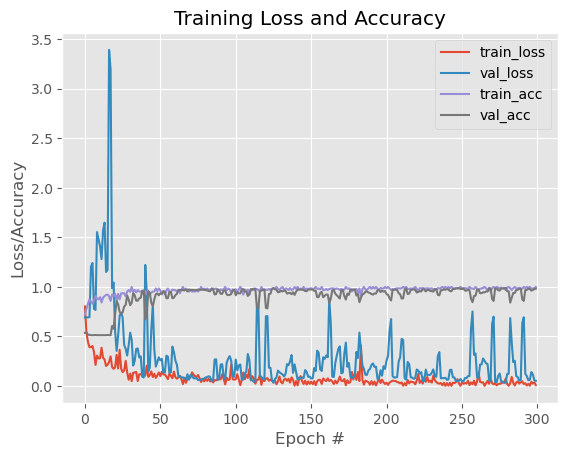

In [10]:

# plot training/validation loss/accuracy
plt.style.use("ggplot")
plt.figure()
N = epochs
plt.plot(np.arange(0,N), H.history["loss"], label="train_loss")
plt.plot(np.arange(0,N), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0,N), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0,N), H.history["val_accuracy"], label="val_acc")

plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend(loc="upper right")

# save plot to disk
plt.savefig('plot.png')

In [11]:
# save the model to disk
#model.save('gender_detection.model')
model.save('gender_detection.keras')

In [13]:
imgread = cv2.imread("dd.png")
f, confidence = cv.detect_face(imgread)
classes = ['man','woman']
D = {}

for i in range(len(f)):
    (startX, startY) = f[i][0], f[i][1]
    (endX, endY) = f[i][2], f[i][3]

        # draw rectangle over face
    cv2.rectangle(imgread, (startX,startY), (endX,endY), (0,255,0), 2)
        # crop the detected face region
    face_crop = np.copy(imgread[startY:endY,startX:endX])
    face_crop = cv2.resize(face_crop, (96,96))
    face_crop = face_crop.astype("float") / 255.0
    face_crop = img_to_array(face_crop)
    face_crop = np.expand_dims(face_crop, axis=0)
    
    # apply gender detection on face
    conf = model.predict(face_crop)[0] # model.predict return a 2D matrix, ex: [[9.9993384e-01 7.4850512e-05]]

    # get label with max accuracy
    idx = np.argmax(conf)
    label = classes[idx]

    label = "{}: {:.2f}%".format(label, conf[idx] * 100)
    print(label)
    if classes[idx] in D:
        D[classes[idx]] += 1
    else:
        D[classes[idx]] = 1
#Y = startY - 10 if startY - 10 > 10 else startY + 10

        # write label and confidence above face rectangle
#cv2.putText(imgread, label, (startX, Y),  cv2.FONT_HER, SHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
#cv2.imshow("gender detection", imgread)
#cv2.waitKey(1)
D

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
man: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
man: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
man: 51.84%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
man: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
man: 99.99%


{'man': 5}